In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv("blood_cell_anomaly_detection (2).csv")

df.head()

,cell_id,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,...,mcv_fl,mchc_g_dl,dataset_source,staining_protocol,microscope_model,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
0,CELL_005371,Hypersegmented_Neutrophil,1,Infection,15.18,58.8,0.542,0.301,0.563,0.529,...,85.5,31.4,CytoData,Giemsa,Zeiss_Axio,100,224,0.7649,0.5726,0.5670
1,CELL_005300,Hypersegmented_Neutrophil,1,Infection,16.47,73.6,0.583,0.365,0.859,0.443,...,92.5,35.0,PBC_Dataset,Wright,Zeiss_Axio,100,224,0.8472,0.7150,0.7273
2,CELL_000200,Neutrophil,0,Normal_WBC,13.41,55.5,0.448,0.376,0.781,0.407,...,76.3,33.0,CytoData,Wright,Leica_DM2000,100,512,0.0313,0.9225,0.9623
3,CELL_003269,Normal_RBC,0,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,...,92.3,32.5,CytoData,Wright,Leica_DM2000,100,512,0.1293,0.9180,0.8652
4,CELL_003505,Normal_RBC,0,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,...,83.9,33.4,CytoData,Wright,Olympus_BX51,100,224,0.1418,0.9697,0.8898


In [5]:
df.isnull().values.any()

np.False_

In [3]:
features = [
    "cell_diameter_um",
    "nucleus_area_pct",
    "chromatin_density",
    "cytoplasm_ratio",
    "circularity",
    "eccentricity",
    "granularity_score",
    "lobularity_score",
    "membrane_smoothness",
    "cell_area_px",
    "perimeter_px"
]

X = df[features]
y = df["anomaly_label"]



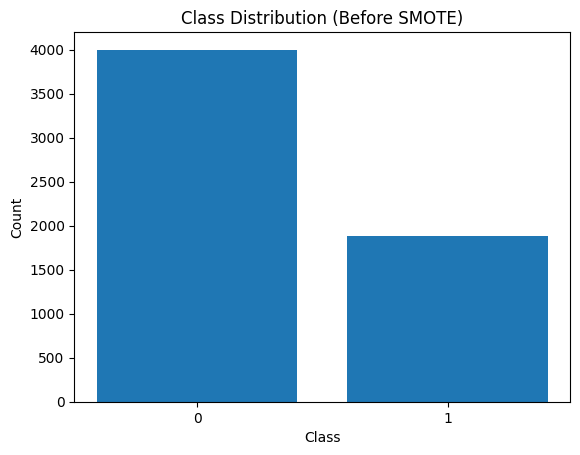

anomaly_label
0    4000
1    1880
Name: count, dtype: int64


In [4]:
counts = y.value_counts()

plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.title("Class Distribution (Before SMOTE)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

print(counts)

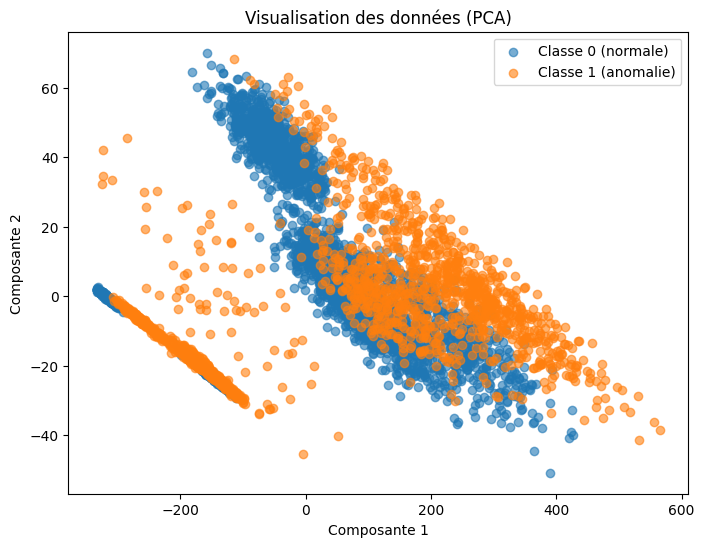

In [4]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)  # X = tes features

# Affichage
plt.figure(figsize=(8,6))

plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], 
            label="Classe 0 (normale)", alpha=0.6)

plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], 
            label="Classe 1 (anomalie)", alpha=0.6)

plt.title("Visualisation des données (PCA)")
plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.legend()
plt.show()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_train_smote).value_counts())

After SMOTE:
anomaly_label
0    3200
1    3200
Name: count, dtype: int64


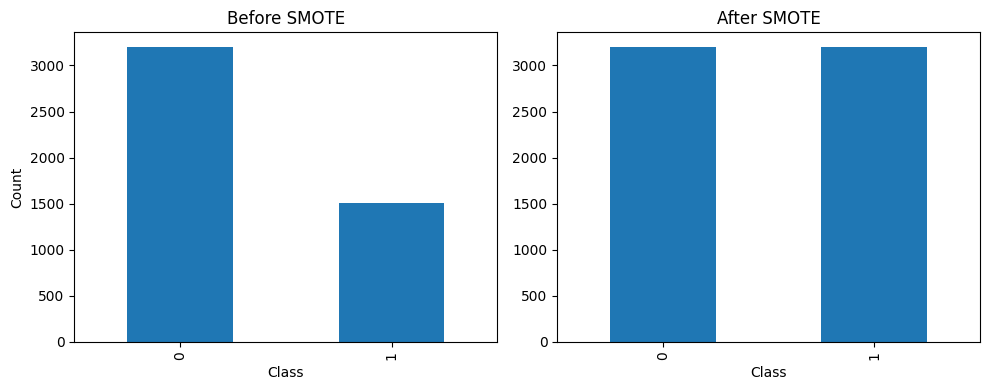

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

# BEFORE SMOTE
pd.Series(y_train).value_counts().plot(kind='bar', ax=ax[0])
ax[0].set_title("Before SMOTE")
ax[0].set_xlabel("Class")
ax[0].set_ylabel("Count")

# AFTER SMOTE
pd.Series(y_train_smote).value_counts().plot(kind='bar', ax=ax[1])
ax[1].set_title("After SMOTE")
ax[1].set_xlabel("Class")

plt.tight_layout()
plt.show()

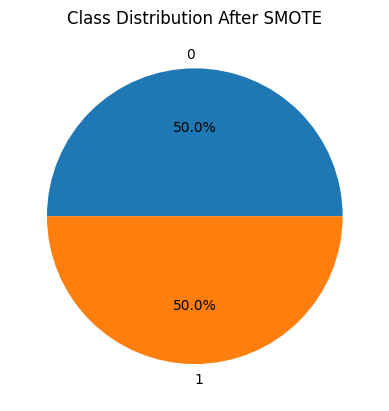

In [10]:
plt.figure()
pd.Series(y_train_smote).value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title("Class Distribution After SMOTE")
plt.ylabel("")
plt.show()

In [8]:
scaler = StandardScaler()

X_train_smote = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

Logistic Regression
Accuracy : 0.7959183673469388
Precision : 0.67

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.83      0.85       800
           1       0.67      0.71      0.69       376

    accuracy                           0.80      1176
   macro avg       0.77      0.77      0.77      1176
weighted avg       0.80      0.80      0.80      1176



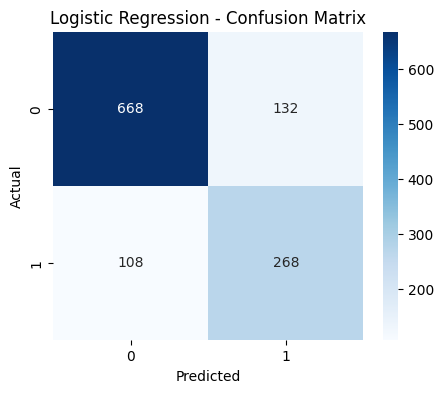

In [10]:
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

import matplotlib.pyplot as plt
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_smote, y_train_smote)
y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression")
print("Accuracy :", accuracy_score(y_test, y_pred_log))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

KNN
Accuracy : 0.9727891156462585
Precision : 0.9574468085106383

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       800
           1       0.96      0.96      0.96       376

    accuracy                           0.97      1176
   macro avg       0.97      0.97      0.97      1176
weighted avg       0.97      0.97      0.97      1176



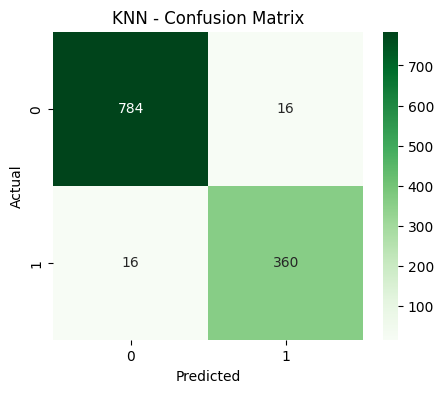

In [11]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_smote, y_train_smote)
y_pred_knn = knn_model.predict(X_test_scaled)

print("KNN")
print("Accuracy :", accuracy_score(y_test, y_pred_knn))



print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn))

cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

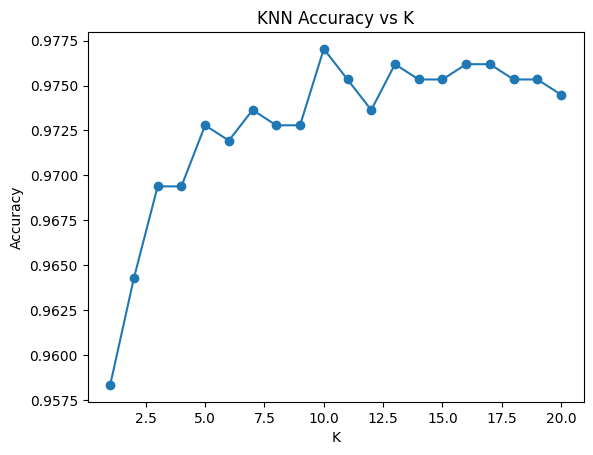

In [16]:
k_values = range(1, 21)
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_smote, y_train_smote)
    y_pred = knn.predict(X_test_scaled)
    scores.append(accuracy_score(y_test, y_pred))

plt.figure()
plt.plot(k_values, scores, marker='o')
plt.title("KNN Accuracy vs K")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()

SVM
Accuracy : 0.9608843537414966
Precision : 0.9741379310344828

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.99      0.97       800
           1       0.97      0.90      0.94       376

    accuracy                           0.96      1176
   macro avg       0.96      0.95      0.95      1176
weighted avg       0.96      0.96      0.96      1176



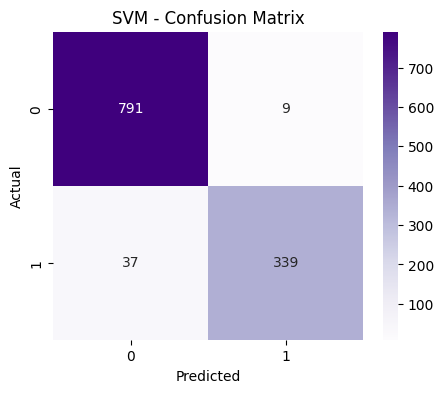

In [12]:
svm_model = SVC(kernel="rbf")

svm_model.fit(X_train_smote, y_train_smote)
y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM")
print("Accuracy :", accuracy_score(y_test, y_pred_svm))


print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Decision Tree
Accuracy : 0.9285714285714286
Precision : 0.8782383419689119

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.94      0.95       800
           1       0.88      0.90      0.89       376

    accuracy                           0.93      1176
   macro avg       0.92      0.92      0.92      1176
weighted avg       0.93      0.93      0.93      1176



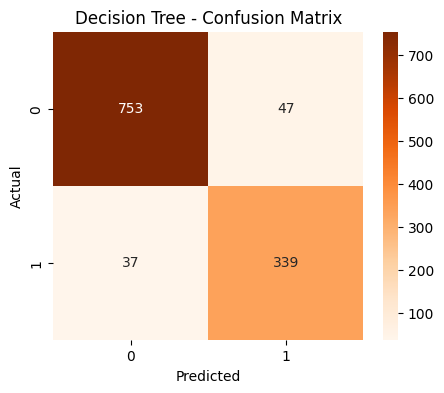

In [13]:
dt_model = DecisionTreeClassifier(max_depth=8, random_state=42)

dt_model.fit(X_train_smote, y_train_smote)
y_pred_dt = dt_model.predict(X_test_scaled)

print("Decision Tree")
print("Accuracy :", accuracy_score(y_test, y_pred_dt))



print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

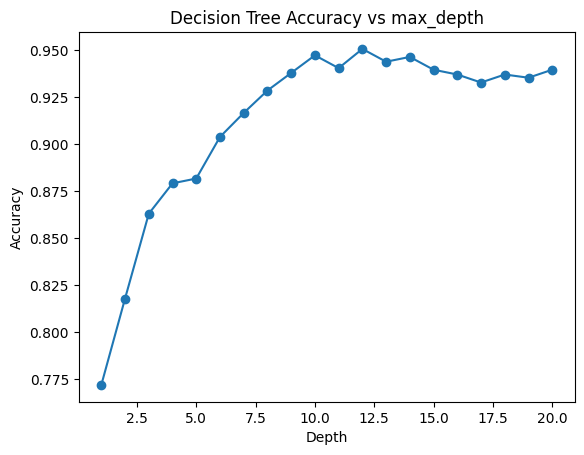

In [17]:
depths = range(1, 21)
scores = []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train_smote, y_train_smote)
    y_pred = tree.predict(X_test_scaled)
    scores.append(accuracy_score(y_test, y_pred))

plt.figure()
plt.plot(depths, scores, marker='o')
plt.title("Decision Tree Accuracy vs max_depth")
plt.xlabel("Depth")
plt.ylabel("Accuracy")
plt.show()

Random Forest
Accuracy : 0.9795918367346939
Precision : 0.9731182795698925

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       800
           1       0.97      0.96      0.97       376

    accuracy                           0.98      1176
   macro avg       0.98      0.98      0.98      1176
weighted avg       0.98      0.98      0.98      1176



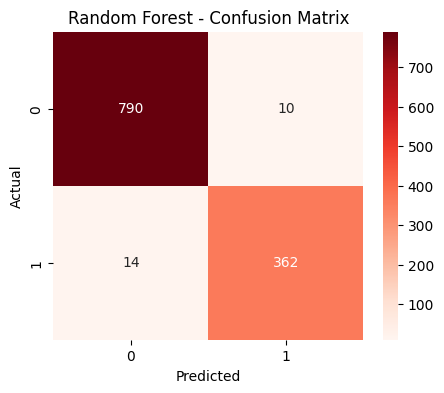

In [31]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train_smote, y_train_smote)
y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))


print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Random Forest (Optimized)
Accuracy : 0.9753401360544217

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       800
           1       0.99      0.93      0.96       376

    accuracy                           0.98      1176
   macro avg       0.98      0.96      0.97      1176
weighted avg       0.98      0.98      0.98      1176



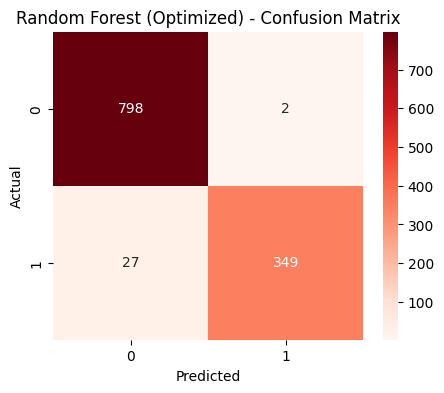

In [25]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train_smote, y_train_smote)
y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest (Optimized)")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")
plt.title("Random Forest (Optimized) - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [21]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel="rbf"),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(name, ":", acc)

best_model = max(results, key=results.get)
print("\nBEST MODEL:", best_model)

Logistic Regression : 0.7959183673469388
KNN : 0.9727891156462585
SVM : 0.9608843537414966
Decision Tree : 0.9285714285714286
Random Forest : 0.9821428571428571

BEST MODEL: Random Forest


In [19]:
results = []

for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])

# trier du meilleur au pire
results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("\nMODEL COMPARISON (WITH SMOTE):")
display(results_df)


MODEL COMPARISON (WITH SMOTE):


,Model,Accuracy
0,Random Forest,0.982143
1,KNN,0.972789
2,SVM,0.960884
3,Decision Tree,0.928571
4,Logistic Regression,0.795918


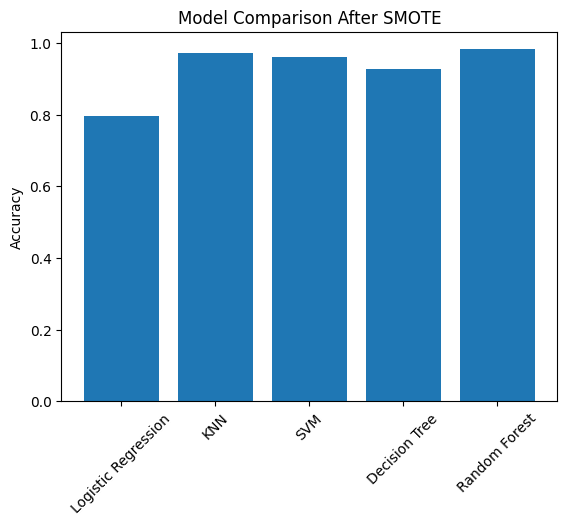

In [22]:
plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Model Comparison After SMOTE")
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.show()